In [1]:
import control as ct
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Sampling time
T = 0.1  # seconds

# Stable system: pole magnitude < 1
num_stable = [0.5]
den_stable = [1, -0.8]  # pole at 0.8
Gz_stable = ct.TransferFunction(num_stable, den_stable, T)

# Unstable system: pole magnitude > 1
num_unstable = [0.5]
den_unstable = [1, 1.2]  # pole at -1.2
Gz_unstable = ct.TransferFunction(num_unstable, den_unstable, T)

In [3]:
poles_stable = Gz_stable.poles()
poles_unstable = Gz_unstable.poles()

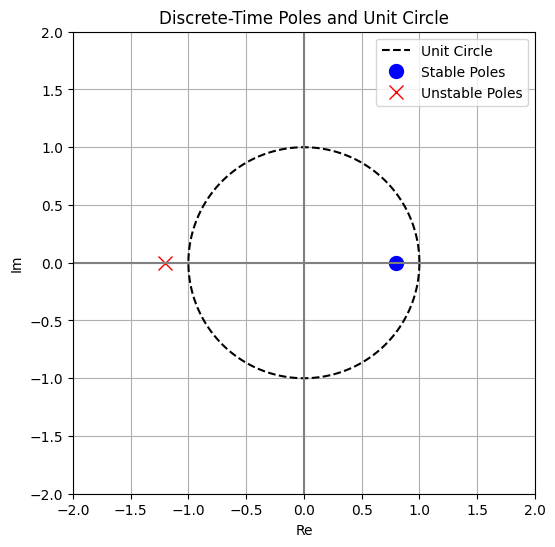

In [4]:
fig, ax = plt.subplots(figsize=(6,6))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit Circle')

# Poles
ax.plot(np.real(poles_stable), np.imag(poles_stable), 'bo', markersize=10, label='Stable Poles')
ax.plot(np.real(poles_unstable), np.imag(poles_unstable), 'rx', markersize=10, label='Unstable Poles')

# Axes and formatting
ax.axhline(0, color='gray')
ax.axvline(0, color='gray')
ax.set_aspect('equal', 'box')
ax.set_xlim([-2, 2])
ax.set_ylim([-2, 2])
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Discrete-Time Poles and Unit Circle')
ax.legend()
ax.grid(True)
plt.show()

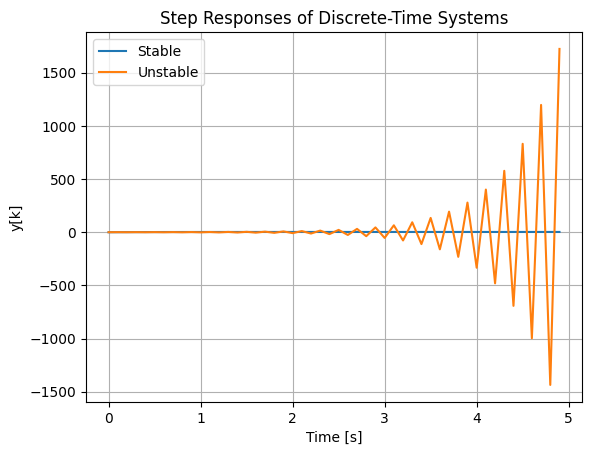

In [5]:
t = np.arange(0, 5, T)
t_out, y_stable = ct.step_response(Gz_stable, t)
t_out, y_unstable = ct.step_response(Gz_unstable, t)

plt.plot(t_out, y_stable, label='Stable')
plt.plot(t_out, y_unstable, label='Unstable')
plt.xlabel('Time [s]')
plt.ylabel('y[k]')
plt.title('Step Responses of Discrete-Time Systems')
plt.legend()
plt.grid(True)
plt.show()